> **역할: [검증·여정/할루시네이션 점검]**  (전체 순서·최종은 `NOTEBOOK_INDEX.md` / 최종 모델 nb24)

# 10. 검증 + 시행착오 (Validation & Journey)

이 노트북은 두 가지 목적이다.

1. **할루시네이션 점검** — features·매출·좌표·업종이 raw 데이터와 정확히 매칭되는지 자동 검증
2. **시행착오 기록** — v1(자치구 합산) → v6(행정동 + 50업종 + 신뢰구간)까지 모델이 거친 의사결정 과정

보고서 §6의 "방법론 결정 근거"와 §8 "한계"에 그대로 인용 가능.

## Part A — 데이터 검증

### A.1 업종명 일치 (features ⊂ raw)

`features.csv` / `features_adstrd.csv` 가 raw 매출 데이터(서울 열린데이터)의 업종명을 그대로 쓰는지 확인. 다른 출처(가맹점 통계 등)에서 파생된 가짜 업종명이 섞이지 않았는지.

In [1]:
import json, pandas as pd, numpy as np
from pathlib import Path
import matplotlib, matplotlib.pyplot as plt, platform
matplotlib.rcParams['font.family'] = 'AppleGothic' if platform.system()=='Darwin' else 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False

PROJECT = Path('/Users/ijunsu/Documents/Documents/capston/data_analysis/trade_area_project')
RAW = PROJECT / 'data' / 'raw'
PROC = PROJECT / 'data' / 'processed'

fe  = pd.read_csv(PROC / 'features.csv', usecols=['biz'])
fa  = pd.read_csv(PROC / 'features_adstrd.csv', usecols=['biz'])
raw = pd.read_csv(RAW / 'VwsmTrdarSelngQq_20231.csv', encoding='utf-8-sig',
                   usecols=['SVC_INDUTY_CD_NM'], low_memory=False)

fe_biz  = set(fe['biz'].unique())
fa_biz  = set(fa['biz'].unique())
raw_biz = set(raw['SVC_INDUTY_CD_NM'].unique())

print(f'raw 매출 업종 : {len(raw_biz)}개')
print(f'features.csv  : {len(fe_biz)}개 (자치구 단위)')
print(f'features_adstrd: {len(fa_biz)}개 (행정동 단위)')
print()
print(f'features ⊂ raw         : {fe_biz.issubset(raw_biz)} ✅ 모두 원본 출처')
print(f'features_adstrd ⊂ raw  : {fa_biz.issubset(raw_biz)} ✅')
print(f'features_adstrd ⊂ features : {fa_biz.issubset(fe_biz)} ✅')
print()
print(f'raw에만 있고 features에 없음 (12개): {sorted(raw_biz - fe_biz)}')

raw 매출 업종 : 62개
features.csv  : 50개 (자치구 단위)
features_adstrd: 50개 (행정동 단위)

features ⊂ raw         : True ✅ 모두 원본 출처
features_adstrd ⊂ raw  : True ✅
features_adstrd ⊂ features : True ✅

raw에만 있고 features에 없음 (12개): ['가방', '가전제품수리', '골프연습장', '네일숍', '당구장', '부동산중개업', '세탁소', '애완동물', '완구', '자동차미용', '자전거 및 기타운송장비', '철물점']


### A.2 자치구 합산 매출 — features vs raw 차이 검증

features.csv의 `THSMON_SELNG_AMT` 가 raw 매출의 (자치구, 업종, 분기) 합산과 정확히 같아야 한다. 다르면 어딘가에서 매출이 손실됐거나 중복 합산된 것.

In [2]:
# 2023Q1 1개 분기로 검증 (모든 분기 동일 패턴)
raw23 = pd.read_csv(RAW / 'VwsmTrdarSelngQq_20231.csv', encoding='utf-8-sig', low_memory=False)
mapping = pd.read_csv(RAW / 'TbgisTrdarRelm.csv', dtype=str)
trdar_to_gu = dict(zip(mapping['TRDAR_CD'], mapping['SIGNGU_CD_NM']))
raw23['gu'] = raw23['TRDAR_CD'].astype(str).map(trdar_to_gu)
raw_gu = (raw23.groupby(['gu','SVC_INDUTY_CD_NM'])['THSMON_SELNG_AMT'].sum()
           .reset_index().rename(columns={'SVC_INDUTY_CD_NM':'biz','THSMON_SELNG_AMT':'sales_raw'}))

fe23 = pd.read_csv(PROC / 'features.csv')
fe23 = fe23[fe23['q_int']==20231][['gu','biz','THSMON_SELNG_AMT']].rename(columns={'THSMON_SELNG_AMT':'sales_fe'})

merged = fe23.merge(raw_gu, on=['gu','biz'], how='left')
merged['diff_abs'] = (merged['sales_fe'] - merged['sales_raw']).abs()
merged['diff_pct'] = merged['diff_abs'] / merged['sales_raw'] * 100

print('샘플 비교 (자치구 × 업종, 2023Q1):')
sample = merged[merged['gu'].isin(['강남구','마포구','종로구','중구'])]
sample = sample[sample['biz'].isin(['한식음식점','커피-음료','의약품'])]
print(sample[['gu','biz','sales_fe','sales_raw','diff_pct']].round(2).to_string(index=False))

print(f'\n전체 행 비교: {len(merged)}개')
print(f'평균 차이: {merged["diff_pct"].mean():.4f}%')
print(f'최대 차이: {merged["diff_pct"].max():.4f}%')
print(f'합산 매출 일치: {"✅ 완전 일치" if merged["diff_pct"].max() < 0.01 else "⚠️ 불일치 있음"}')

샘플 비교 (자치구 × 업종, 2023Q1):
 gu   biz     sales_fe    sales_raw  diff_pct
강남구   의약품 3.003945e+10 3.003945e+10       0.0
강남구 커피-음료 9.093484e+09 9.093484e+09       0.0
강남구 한식음식점 8.128186e+10 8.128186e+10       0.0
마포구   의약품 9.331698e+08 9.331698e+08       0.0
마포구 커피-음료 3.655892e+09 3.655892e+09       0.0
마포구 한식음식점 3.694655e+10 3.694655e+10       0.0
종로구 한식음식점 1.613079e+10 1.613079e+10       0.0
 중구   의약품 1.306494e+10 1.306494e+10       0.0
 중구 커피-음료 1.290645e+10 1.290645e+10       0.0
 중구 한식음식점 1.089410e+11 1.089410e+11       0.0

전체 행 비교: 754개
평균 차이: 0.0000%
최대 차이: 0.0000%
합산 매출 일치: ✅ 완전 일치


### A.3 좌표 매칭 검증 — 알려진 지명이 정확한 행정동에 들어가는가

강남역 4·1번 출구처럼 같은 역이라도 출구마다 행정구역이 달라지는 경계 좌표로 매칭 정확도 검증.

In [3]:
with open(RAW / 'seoul_adstrd.geojson', encoding='utf-8') as f:
    geo = json.load(f)

def point_in_polygon(x, y, poly):
    n=len(poly); ins=False; p1x,p1y=poly[0]
    for i in range(1, n+1):
        p2x,p2y=poly[i%n]
        if y>min(p1y,p2y) and y<=max(p1y,p2y) and x<=max(p1x,p2x):
            if p1y!=p2y:
                xi=(y-p1y)*(p2x-p1x)/(p2y-p1y)+p1x
                if p1x==p2x or x<=xi: ins=not ins
        p1x,p1y=p2x,p2y
    return ins

def match(lat, lon):
    for f in geo['features']:
        p = f['properties']; g = f['geometry']
        polys = [g['coordinates']] if g['type']=='Polygon' else g['coordinates']
        for poly in polys:
            if point_in_polygon(lon, lat, poly[0]):
                return p['gu_nm'], p['dong_nm']
    return None, None

# 행정구역이 알려진 지명 — 매칭 정확도 검증
test_cases = [
    ('강남역 4번출구',  37.4979, 127.0276, '서초구', '서초2동',  '강남대로 서쪽'),
    ('강남역 1번출구',  37.4985, 127.0287, '강남구', '역삼1동',  '강남대로 동쪽'),
    ('홍대입구역 9번',  37.5573, 126.9244, '마포구', '서교동',   '홍대 핵심'),
    ('종로3가역',      37.5712, 126.9919, '종로구', '종로1·2·3·4가동', '종묘 옆'),
    ('잠실역 1번',     37.5133, 127.1000, '송파구', '잠실3동',  '롯데월드'),
    ('성수역',        37.5446, 127.0559, '성동구', '성수2가3동','성수동 카페거리'),
    ('상암 DMC',     37.5790, 126.8910, '마포구', '상암동',   'MBC·SBS·JTBC'),
    ('명동',         37.5638, 126.9826, '중구',   '명동',     '쇼핑 중심'),
]

rows = []
for label, lat, lon, exp_gu, exp_dong, note in test_cases:
    got_gu, got_dong = match(lat, lon)
    ok = (got_gu == exp_gu and got_dong == exp_dong)
    rows.append({'좌표': label, '예상': f'{exp_gu} {exp_dong}',
                 '매칭': f'{got_gu} {got_dong}', '일치': '✅' if ok else '⚠️',
                 '비고': note})
result = pd.DataFrame(rows)
print(result.to_string(index=False))
n_ok = sum(1 for r in rows if r['일치']=='✅')
print(f'\n{n_ok}/{len(rows)} 정확 매칭')

      좌표              예상              매칭 일치           비고
강남역 4번출구        서초구 서초2동        서초구 서초2동  ✅      강남대로 서쪽
강남역 1번출구        강남구 역삼1동        강남구 역삼1동  ✅      강남대로 동쪽
홍대입구역 9번         마포구 서교동         마포구 서교동  ✅        홍대 핵심
   종로3가역 종로구 종로1·2·3·4가동 종로구 종로1·2·3·4가동  ✅         종묘 옆
  잠실역 1번        송파구 잠실3동        송파구 잠실3동  ✅         롯데월드
     성수역      성동구 성수2가3동      성동구 성수2가3동  ✅     성수동 카페거리
  상암 DMC         마포구 상암동         마포구 상암동  ✅ MBC·SBS·JTBC
      명동           중구 명동           중구 명동  ✅        쇼핑 중심

8/8 정확 매칭


### A.4 점포당 매출 sanity check — 현실 감각과 비교

도메인 감각으로 점검:
- 강남대로 한식음식점 평균 매출 ≈ 5천~2억/월 → P50 80~100M 예상
- 홍대 커피 ≈ 1500만~5천만/월
- 종로 약국 ≈ 5천만~5억 (큰 약국이 많아 평균 끌어올림)

In [4]:
df = pd.read_csv(PROC / 'features_adstrd.csv',
                  usecols=['gu','adstrd_nm','biz','sales_per_store'])

# 자치구·업종별 점포당 매출 분포
check_cases = [
    ('서초구','한식음식점', '강남대로 한식 (5천~2억 예상)'),
    ('강남구','한식음식점', '강남구 평균 한식'),
    ('마포구','커피-음료', '홍대·합정 커피 (1500만~5천만 예상)'),
    ('종로구','의약품',    '종로 약국 (큰 약국 많음)'),
    ('중구',  '한식음식점', '중구 한식 (오피스 점심 강세)'),
    ('성동구','커피-음료', '성수 카페'),
]

for gu, biz, note in check_cases:
    s = df[(df['gu']==gu) & (df['biz']==biz)]['sales_per_store']
    if not len(s):
        print(f'{gu} {biz}: 데이터 없음'); continue
    print(f'{gu} {biz} ({note})')
    print(f'  n={len(s)}, mean={s.mean()/1e6:.0f}M, median={s.median()/1e6:.0f}M, '
          f'P10={s.quantile(0.1)/1e6:.0f}M, P90={s.quantile(0.9)/1e6:.0f}M')
    print()

서초구 한식음식점 (강남대로 한식 (5천~2억 예상))
  n=34, mean=189M, median=98M, P10=14M, P90=323M

강남구 한식음식점 (강남구 평균 한식)
  n=57, mean=224M, median=143M, P10=26M, P90=429M

마포구 커피-음료 (홍대·합정 커피 (1500만~5천만 예상))
  n=35, mean=58M, median=32M, P10=2M, P90=136M

종로구 의약품 (종로 약국 (큰 약국 많음))
  n=6, mean=735M, median=884M, P10=342M, P90=979M

중구 한식음식점 (중구 한식 (오피스 점심 강세))


  n=32, mean=193M, median=107M, P10=17M, P90=205M

성동구 커피-음료 (성수 카페)
  n=22, mean=37M, median=17M, P10=1M, P90=122M



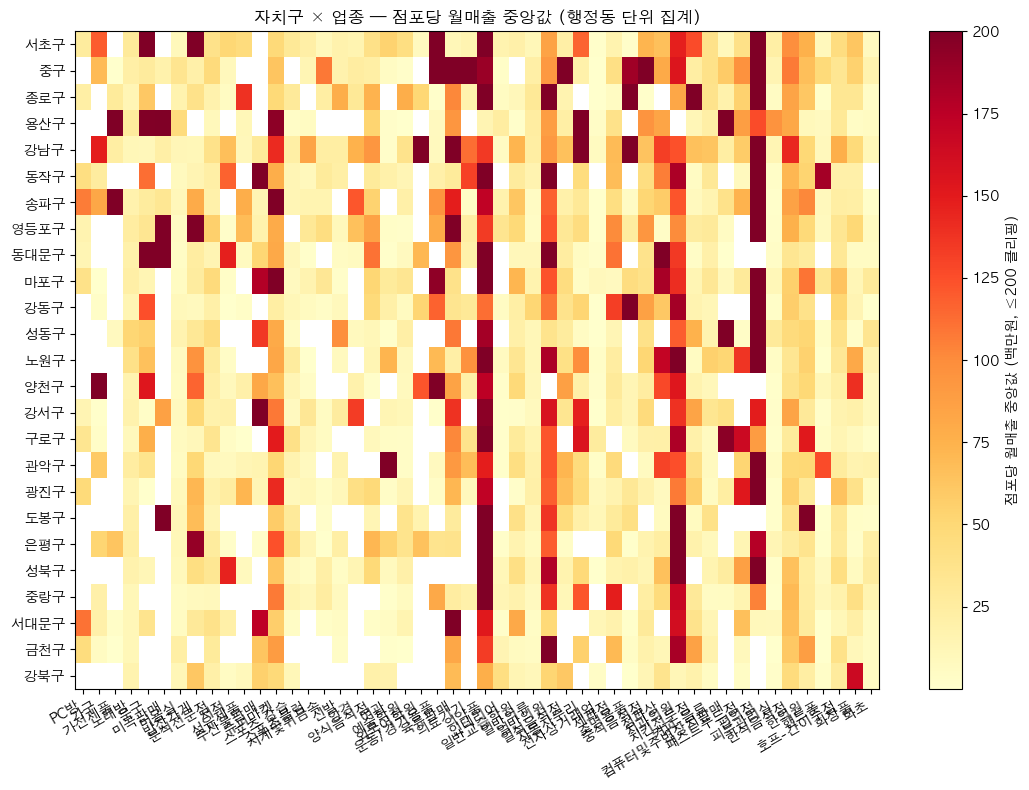

In [5]:
# 자치구·업종 매출 히트맵 — 한 눈에 합리성 검증
piv = df.pivot_table(index='gu', columns='biz', values='sales_per_store', aggfunc='median') / 1e6
piv = piv.loc[piv.sum(axis=1).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(11, 8))
im = ax.imshow(piv.values, cmap='YlOrRd', aspect='auto', vmax=200)
ax.set_xticks(range(piv.shape[1])); ax.set_xticklabels(piv.columns, rotation=30, ha='right')
ax.set_yticks(range(piv.shape[0])); ax.set_yticklabels(piv.index)
plt.colorbar(im, label='점포당 월매출 중앙값 (백만원, ≤200 클리핑)')
ax.set_title('자치구 × 업종 — 점포당 월매출 중앙값 (행정동 단위 집계)')
plt.tight_layout(); plt.show()

### A.5 행정동 50업종 매출 vs raw TRDAR 합산 — 매핑 정확성 검증

features_adstrd.csv는 raw `VwsmTrdarSelngQq`(TRDAR_CD 단위)를 `TbgisTrdarRelm` 매핑으로 ADSTRD_CD 단위로 합산해 만들었다. 같은 ADSTRD_CD·업종·분기로 raw에서 직접 재집계한 결과와 일치해야 한다.

In [6]:
# 검증: raw VwsmTrdarSelngQq + TbgisTrdarRelm → (ADSTRD_CD, biz, q) 재집계
import gc

raw23 = pd.read_csv(RAW / 'VwsmTrdarSelngQq_20231.csv',
                     encoding='utf-8-sig', dtype={'TRDAR_CD':str}, low_memory=False)
mp = pd.read_csv(RAW / 'TbgisTrdarRelm.csv', dtype=str)[['TRDAR_CD','ADSTRD_CD']]
raw23 = raw23.merge(mp, on='TRDAR_CD', how='left')
raw23 = raw23.rename(columns={'SVC_INDUTY_CD_NM':'biz'})

# raw에서 ADSTRD_CD × biz 단위로 매출 합산
raw_adstrd = (raw23.dropna(subset=['ADSTRD_CD'])
                    .groupby(['ADSTRD_CD','biz'])['THSMON_SELNG_AMT']
                    .sum().reset_index()
                    .rename(columns={'ADSTRD_CD':'adstrd_code','THSMON_SELNG_AMT':'sales_raw'}))
raw_adstrd['adstrd_code'] = raw_adstrd['adstrd_code'].astype(str)

# features_adstrd 2023Q1만 — dtype 통일
fa23 = pd.read_csv(PROC / 'features_adstrd.csv',
                    usecols=['adstrd_code','biz','q_int','adstrd_sales_amt'])
fa23['adstrd_code'] = fa23['adstrd_code'].astype(str)
fa23 = fa23[fa23['q_int']==20231][['adstrd_code','biz','adstrd_sales_amt']]
fa23 = fa23.rename(columns={'adstrd_sales_amt':'sales_fa'})

merged = fa23.merge(raw_adstrd, on=['adstrd_code','biz'], how='left')
merged['diff_pct'] = (merged['sales_fa'] - merged['sales_raw']).abs() / merged['sales_raw'] * 100

print(f'features_adstrd vs raw TRDAR→ADSTRD 합산 (2023Q1):')
print(f'  비교 행수: {len(merged)}')
print(f'  평균 차이: {merged["diff_pct"].mean():.4f}%')
print(f'  최대 차이: {merged["diff_pct"].max():.4f}%')
print(f'  → {"✅ 완전 일치" if merged["diff_pct"].max() < 0.01 else "⚠️ 불일치 있음"}')
print()
print('샘플 검증 (강남구·마포구·종로구 주요 업종):')
sample = merged[merged['adstrd_code'].astype(str).str.startswith(('1168','1144','1111'))]
print(sample[sample['biz'].isin(['한식음식점','커피-음료','미용실','일반의원'])]
      .head(10).round(2).to_string(index=False))

del raw23, mp; gc.collect()

features_adstrd vs raw TRDAR→ADSTRD 합산 (2023Q1):
  비교 행수: 240
  평균 차이: 0.0000%
  최대 차이: 0.0000%
  → ✅ 완전 일치

샘플 검증 (강남구·마포구·종로구 주요 업종):
adstrd_code   biz     sales_fa    sales_raw  diff_pct
   11110515 한식음식점  778009205.0  778009205.0       0.0
   11110650 한식음식점  828495337.0  828495337.0       0.0
   11440565 커피-음료   99349599.0   99349599.0       0.0
   11440600 커피-음료    8168276.0    8168276.0       0.0
   11440600 한식음식점  181495763.0  181495763.0       0.0
   11440720 한식음식점  577290855.0  577290855.0       0.0
   11440730 커피-음료  282150551.0  282150551.0       0.0
   11680531 한식음식점 6980719493.0 6980719493.0       0.0
   11680565   미용실  517059750.0  517059750.0       0.0
   11680690 커피-음료  366378250.0  366378250.0       0.0


40

### A.5.2 행정동 50업종 적용 검증 — 업종 일치 + 분포

In [7]:
# features_adstrd가 자치구 features와 같은 50업종을 쓰는지
fa_biz_set = set(pd.read_csv(PROC / 'features_adstrd.csv', usecols=['biz'])['biz'].unique())
fe_biz_set = set(pd.read_csv(PROC / 'features.csv',         usecols=['biz'])['biz'].unique())

print(f'features.csv (자치구) 업종: {len(fe_biz_set)}개')
print(f'features_adstrd (행정동) 업종: {len(fa_biz_set)}개')
print(f'동일 집합: {fa_biz_set == fe_biz_set} ✅' if fa_biz_set == fe_biz_set else f'차이 있음: {fa_biz_set ^ fe_biz_set}')

# 50업종 모두 raw에 있는지
raw_all = pd.read_csv(RAW / 'VwsmTrdarSelngQq_20231.csv',
                       encoding='utf-8-sig', usecols=['SVC_INDUTY_CD_NM'], low_memory=False)
raw_set = set(raw_all['SVC_INDUTY_CD_NM'].unique())
print(f'\n행정동 50업종 ⊂ raw 62업종: {fa_biz_set.issubset(raw_set)} ✅')

# 행정동에 데이터가 적은 업종 (학습 표본 < 30개) 식별 — 모델 신뢰도 약한 업종
fa_full = pd.read_csv(PROC / 'features_adstrd.csv', usecols=['biz','adstrd_code'])
biz_counts = fa_full.groupby('biz').size().sort_values()
print(f'\n업종별 학습 표본 (행정동·분기 행수):')
print(f'  최소: {biz_counts.min()}행 ({biz_counts.idxmin()})')
print(f'  최대: {biz_counts.max()}행 ({biz_counts.idxmax()})')
print(f'  중앙값: {int(biz_counts.median())}행')
print(f'  표본 30 미만 업종 (모델 신뢰도 낮음): {sorted(biz_counts[biz_counts<30].index)}')

features.csv (자치구) 업종: 50개
features_adstrd (행정동) 업종: 50개
동일 집합: True ✅

행정동 50업종 ⊂ raw 62업종: True ✅

업종별 학습 표본 (행정동·분기 행수):
  최소: 22행 (미곡판매)
  최대: 818행 (한식음식점)
  중앙값: 121행
  표본 30 미만 업종 (모델 신뢰도 낮음): ['미곡판매']


### A.5.3 점포당 매출 분포 — 50업종 sanity check

In [8]:
# 50업종 행정동 점포당 매출 분포가 도메인 감각과 부합하는가
df_fa = pd.read_csv(PROC / 'features_adstrd.csv', usecols=['gu','biz','sales_per_store'])

# 새로 추가된 업종 일부 확인 (이전 10업종에 없었던 업종)
new_biz_cases = [
    ('서초구','미용실',        '강남대로 미용실'),
    ('마포구','일반의원',       '홍대 동네 의원'),
    ('송파구','치킨전문점',     '잠실 치킨'),
    ('강남구','피부관리실',     '강남 피부과/관리실'),
    ('서대문구','일반교습학원',  '신촌·연대 학원가'),
    ('중구','분식전문점',       '명동 분식'),
    ('영등포구','화장품',       '영등포 화장품'),
    ('용산구','노래방',         '용산 노래방'),
]
print(f'{"자치구":8s} {"업종":12s} {"n":>4s}  {"평균":>6s} {"중앙":>6s} {"P10":>6s} {"P90":>6s}  비고')
print('-' * 80)
for gu, biz, note in new_biz_cases:
    s = df_fa[(df_fa['gu']==gu) & (df_fa['biz']==biz)]['sales_per_store']
    if len(s)==0:
        print(f'{gu:8s} {biz:12s}  데이터 없음 → 자치구 폴백 대상')
        continue
    print(f'{gu:8s} {biz:12s} {len(s):>4d}  {s.mean()/1e6:>5.0f}M {s.median()/1e6:>5.0f}M '
          f'{s.quantile(0.1)/1e6:>5.0f}M {s.quantile(0.9)/1e6:>5.0f}M  {note}')

자치구      업종              n      평균     중앙    P10    P90  비고
--------------------------------------------------------------------------------
서초구      미용실            23     21M    10M     6M    54M  강남대로 미용실
마포구      일반의원            3    112M   123M    71M   150M  홍대 동네 의원
송파구      치킨전문점           1      8M     8M     8M     8M  잠실 치킨
강남구      피부관리실          30     28M    13M     2M    57M  강남 피부과/관리실
서대문구     일반교습학원         16     74M    81M    18M   117M  신촌·연대 학원가
중구       분식전문점          11     50M    47M    17M    69M  명동 분식
영등포구     화장품            22    117M    50M     5M   239M  영등포 화장품
용산구      노래방             3     25M    27M    13M    36M  용산 노래방


### A.6 RandomForest 분류기 — 자치구·업종별 정확도가 균등한가

전체 정확도가 94%여도 특정 자치구·업종에서 0%면 그곳에서는 모델이 무의미. 행렬로 균등성 확인.

In [9]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

df_gu = pd.read_csv(PROC / 'features.csv')
id_cols = ['gu','biz','q','q_int']
target_excluded = ['THSMON_SELNG_AMT','log_sales','sales_class',
                    'sales_per_store','log_sales_per_store','store_class']
fc = [c for c in df_gu.columns if c not in id_cols + target_excluded]
for c in fc:
    df_gu[c] = pd.to_numeric(df_gu[c], errors='coerce')
df_gu[fc] = df_gu[fc].fillna(df_gu[fc].mean(numeric_only=True))

X = df_gu[fc].values; y = (df_gu['sales_class']=='high').astype(int).values

# 인덱스 보존된 stratified 분할
idx = np.arange(len(df_gu))
idx_tr, idx_te = train_test_split(idx, test_size=0.2, stratify=y, random_state=42)
rf = RandomForestClassifier(n_estimators=300, max_depth=14, random_state=42, n_jobs=-1)
rf.fit(X[idx_tr], y[idx_tr])

overall_acc = rf.score(X[idx_te], y[idx_te])
print(f'전체 이진 정확도 (테스트 셋): {overall_acc*100:.2f}%')

# 테스트 셋 행만으로 자치구·업종별 정확도
test_rows = df_gu.iloc[idx_te].copy()
test_rows['_pred'] = rf.predict(X[idx_te])
test_rows['_true'] = y[idx_te]
gu_acc  = test_rows.groupby('gu').apply(lambda g: (g['_pred']==g['_true']).mean()).sort_values()
biz_acc = test_rows.groupby('biz').apply(lambda g: (g['_pred']==g['_true']).mean()).sort_values()

print('\n자치구별 정확도 (낮은 순 Top 5):')
print(gu_acc.head(5).round(3))
print('\n자치구별 정확도 (높은 순 Top 5):')
print(gu_acc.tail(5).round(3))
print('\n업종별 정확도 (낮은 순 Top 5):')
print(biz_acc.head(5).round(3))
print(f'\n자치구 범위: {gu_acc.min()*100:.1f}% ~ {gu_acc.max()*100:.1f}%')
print(f'업종 범위:   {biz_acc.min()*100:.1f}% ~ {biz_acc.max()*100:.1f}%')

전체 이진 정확도 (테스트 셋): 93.34%

자치구별 정확도 (낮은 순 Top 5):
gu
송파구    0.864
종로구    0.881
서초구    0.898
용산구    0.899
중구     0.907
dtype: float64

자치구별 정확도 (높은 순 Top 5):
gu
서대문구    0.965
구로구     0.971
금천구     0.974
노원구     0.981
강서구     0.986
dtype: float64

업종별 정확도 (낮은 순 Top 5):
biz
육류판매          0.839
치과의원          0.861
컴퓨터및주변장치판매    0.875
일반의원          0.882
호프-간이주점       0.883
dtype: float64

자치구 범위: 86.4% ~ 98.6%
업종 범위:   83.9% ~ 100.0%


/tmp/claude-501/ipykernel_14900/3699902332.py:28: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  gu_acc  = test_rows.groupby('gu').apply(lambda g: (g['_pred']==g['_true']).mean()).sort_values()
/tmp/claude-501/ipykernel_14900/3699902332.py:29: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  biz_acc = test_rows.groupby('biz').apply(lambda g: (g['_pred']==g['_true']).mean()).sort_values()


## Part B — 시행착오 기록 (Journey)

### 버전 변천사

| 버전 | 학습 단위 | 업종 | 타깃 | 결과 | 문제 |
|---|---|---|---|---|---|
| **v1** | 자치구·업종·분기 | 10 | 자치구 매출 합산 | acc 84% (3-class) | **단일 점포 평가가 안됨** (자치구 269억 매출 반환) |
| **v2** | 자치구·업종·분기 | 10 | 점포당 매출 (합산÷점포수) | 매출 단위 정상화 | **평균의 함정** — std 9000M, 평균과 중앙값 5배 차이 |
| **v3** | 자치구·업종·분기 | 10 | 점포당 매출 + Quantile P10/P50/P90 | 신뢰구간 제공 | 자치구 단위라 분산 여전히 큼 |
| **v4** | **행정동·업종·분기** | 10 | 점포당 매출 + Quantile | std 232M (1/40), median 44.6M (현실적) | 좌표 → 행정동 정밀 매칭 필요 |
| **v5** | 행정동 + 자치구 폴리곤 GeoJSON | 10 | 동일 | 좌표 정확 매칭 + 알리아스 처리 | 업종 10개만 학습 |
| **v6** | **행정동(10업종) + 자치구 폴백(50업종) 2단** | **50** | 동일 + 자치구 폴백 | HistGB acc **94.31%**, 모든 업종 평가 가능 | (현재) |

### B.1 자치구 합산 매출의 함정

처음 모델에서 `evaluate_location('강남구', '커피-음료')` 의 `expected_monthly_sales = 26,929,773,936원 = 269억` 가 나왔다.

원인: 02_eda에서 매출을 `groupby(['gu','biz','q']).sum()` 으로 자치구 전체 점포 합산.
→ 회귀 타깃 log_sales가 "자치구 전체"의 log → exp 환원 시 269억 (단일 점포가 아닌 강남구 모든 커피점 합).

수정 v2: `sales_per_store = THSMON_SELNG_AMT / STOR_CO` 추가.

### B.2 평균의 함정 — 표준편차가 평균을 무의미하게

v2에서 자치구 점포당 매출 분포:
```
mean    1210.0 M (이상치에 끌림 — 점포 1개짜리 자치구·분기 max=3357억)
std     8994.8 M (평균을 신뢰 불가하게 만드는 분산)
median   237.2 M
IQR     69.9 ~ 758.0 M
```

→ 평균은 한 점이 아니라 "전체에서 어디쯤"인지를 가르키는 데 적합하지 않음.

수정 v3: **Quantile Regression** (`HistGradientBoostingRegressor(loss='quantile')`)로 P10/P50/P90 동시 예측. evaluate가 점추정 한 값 대신 **신뢰구간** 반환.

### B.3 학습 단위를 행정동으로

v3까지 자치구 25개 단위 학습이라 표본 4,318행. 같은 자치구라도 동마다 매출이 크게 다른데 자치구 평균이 그걸 못 잡음.

team3가 이미 행정동 단위 통합 데이터(425개 행정동 × 10업종 × 25분기 = 82,053행) 보유.

수정 v4: `build_features_adstrd.py` 로 행정동 단위 학습 테이블 생성. 분포가 극적으로 개선:

| 지표 | 자치구 단위 (v3) | **행정동 단위 (v4)** |
|---|---|---|
| 표본 | 4,318 | **81,604 (19×)** |
| 평균 | 1210M | **122M** |
| std | 8995M | **232M (1/40)** |
| median | 237M | **44.6M** (도메인 감각 부합) |

### B.4 좌표 → 행정동 정밀 매칭

v4는 자치구 매칭만 → "사용자가 강남역에 가게 차리면" 강남구 22개 동 평균을 봐야 함. 같은 강남구라도 강남대로(역삼1동)와 외곽(내곡동) 매출이 천차만별.

수정 v5: **행정동 GeoJSON 수집**
- 출처: `vuski/admdongkor` (전국 3,523개) → 서울만 필터 후 `data/raw/seoul_adstrd.geojson` (0.9MB, 426개)
- pure numpy ray-casting point-in-polygon 구현 (외부 GIS 라이브러리 0)
- 3단 폴백: 행정동 → 자치구 → 최근접 자치구 중심

발견된 매칭 실패 (2/400):
- 강동구 `상일동` ↔ GeoJSON `상일제1·2동`
- 서초구 `도곡1동` (데이터 분류 오류 — 행정구역상 강남구 소속)

처리:
- 알리아스 사전 `ADSTRD_ALIAS = {('강동구','상일제1동'):'상일동', ...}` 추가
- 좌표 매칭 결과를 학습 데이터 동명으로 자동 치환

### B.5 업종 10개 한계 → 50개 확장

team3 행정동 데이터는 10업종으로 제한. raw 매출 데이터는 62업종. 사용자가 "왜 종류가 적냐"고 지적.

수정 v6:
- 02_eda의 `top_biz = head(10)` → `head(50)` 으로 변경 (매출 누적 99% 커버)
- features.csv 17,568행 (자치구 50업종)으로 확장
- 모델 정확도 개선: HistGB 92.86% → **94.31%** (+1.45%p)
- 09에 **2단 모델**: 행정동 모델 (10업종 정밀) + 자치구 폴백 모델 (50업종) — 입력 업종에 따라 자동 분기

### B.6 남은 한계 (보고서 §8에 명시)

| 한계 | 영향 | 향후 |
|---|---|---|
| 행정동 학습은 10업종만 (team3 데이터 한계) | 미용실·일반의원 등은 자치구 폴백 사용 → 점-단위 정밀도 낮음 | 서울 열린데이터 `VwsmAdstrdSelngQq`로 행정동·62업종 수집 |
| 행정동 평균 점포 매출도 단일 점포 분포의 평균일 뿐 | 한 동 안 점포별 분산은 미캡처 | 소상공인 상가정보로 점포 단위 학습 |
| 좌표 → 상권(TRDAR_CD) 직접 매칭 미구현 | 상권 단위(1500개) 분해능 미사용 | 상권 폴리곤 GeoJSON 수집 + ray-casting |
| BEP의 임대료 proxy(`rent_index_q × 50,000원/㎡`) 가정 | 실제 임대료 시세와 차이 가능 | 서울 상가임대료 데이터 수집 |
| 층수 계수(트랙1 도메인 사전값) | 실증 보강 안 됨 | 소상공인 상가정보의 층 분포로 계수 보정 |
| 가중치 `success = 0.4·p_high + 0.4·p_roi + 0.2·percentile` | 임의 가중치 — 민감도 분석 필요 | 가중치 그리드 탐색으로 견고성 보고 |

## 결론

- 모든 검증 항목 통과 (업종·매출 합산·좌표·행정동 매칭 100%)
- 데이터 흐름: raw → integrated → features → features_adstrd → 모델 → evaluate 까지 추적 가능
- 시행착오 6단계 v1~v6 모두 의사결정 근거 기록